#Predicting Stock Prices: Develop a time series prediction model to forecast stock prices.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model as ln

In [6]:
df = pd.read_csv('/content/drive/MyDrive/AML_Lab/stock_price_with_price_column.csv')
df

,Date,Stock,Open,High,Low,Close,Volume,Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667
...,...,...,...,...,...,...,...,...
6520,2024-12-25,TSLA,225.09,225.21,221.66,223.18,9701165,223.350000
6521,2024-12-26,TSLA,222.07,222.87,220.31,220.32,6045143,221.166667
6522,2024-12-27,TSLA,219.94,221.69,218.38,219.57,8512677,219.880000
6523,2024-12-30,TSLA,219.54,220.33,216.70,217.33,9137479,218.120000


In [7]:
df.head()

,Date,Stock,Open,High,Low,Close,Volume,Price
0,2020-01-01,AAPL,173.80,174.75,173.68,174.43,8204212,174.286667
1,2020-01-02,AAPL,176.01,177.59,174.07,177.55,2766891,176.403333
2,2020-01-03,AAPL,177.57,178.37,176.62,176.71,5721339,177.233333
3,2020-01-06,AAPL,176.01,177.58,171.33,171.73,9242680,173.546667
4,2020-01-07,AAPL,171.85,172.20,170.69,170.82,4416664,171.236667


In [8]:
l = []
l = df.columns

In [9]:
print(l)

Index(['Date', 'Stock', 'Open', 'High', 'Low', 'Close', 'Volume', 'Price'], dtype='object')


In [10]:
df = pd.get_dummies(df,columns=["Stock"],drop_first=True)
df

,Date,Open,High,Low,Close,Volume,Price,Stock_AMZN,Stock_GOOGL,Stock_MSFT,Stock_TSLA
0,2020-01-01,173.80,174.75,173.68,174.43,8204212,174.286667,False,False,False,False
1,2020-01-02,176.01,177.59,174.07,177.55,2766891,176.403333,False,False,False,False
2,2020-01-03,177.57,178.37,176.62,176.71,5721339,177.233333,False,False,False,False
3,2020-01-06,176.01,177.58,171.33,171.73,9242680,173.546667,False,False,False,False
4,2020-01-07,171.85,172.20,170.69,170.82,4416664,171.236667,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6520,2024-12-25,225.09,225.21,221.66,223.18,9701165,223.350000,False,False,False,True
6521,2024-12-26,222.07,222.87,220.31,220.32,6045143,221.166667,False,False,False,True
6522,2024-12-27,219.94,221.69,218.38,219.57,8512677,219.880000,False,False,False,True
6523,2024-12-30,219.54,220.33,216.70,217.33,9137479,218.120000,False,False,False,True


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,Price,Stock_AMZN,Stock_GOOGL,Stock_MSFT,Stock_TSLA
0,2020-01-01,173.80,174.75,173.68,174.43,8204212,174.286667,False,False,False,False
1,2020-01-02,176.01,177.59,174.07,177.55,2766891,176.403333,False,False,False,False
2,2020-01-03,177.57,178.37,176.62,176.71,5721339,177.233333,False,False,False,False
3,2020-01-06,176.01,177.58,171.33,171.73,9242680,173.546667,False,False,False,False
4,2020-01-07,171.85,172.20,170.69,170.82,4416664,171.236667,False,False,False,False


In [12]:
df= df.sort_values(by='Date')
df.head()

,Date,Open,High,Low,Close,Volume,Price,Stock_AMZN,Stock_GOOGL,Stock_MSFT,Stock_TSLA
0,2020-01-01,173.80,174.75,173.68,174.43,8204212,174.286667,False,False,False,False
5220,2020-01-01,180.85,182.27,179.04,181.23,9329687,180.846667,False,False,False,True
1305,2020-01-01,297.63,299.95,297.16,298.95,9309740,298.686667,False,True,False,False
2610,2020-01-01,146.91,149.11,146.83,147.56,6812085,147.833333,False,False,True,False
3915,2020-01-01,199.85,200.03,197.54,199.28,8323800,198.950000,True,False,False,False


In [14]:
lm = ln.LinearRegression()

In [15]:
df.shape

(6525, 11)

In [16]:
x=df[["Open","High","Low","Volume","Stock_AMZN","Stock_GOOGL","Stock_MSFT","Stock_TSLA"]]
y=df["Close"]

In [17]:
x_train = x[0:5220]
x_test = x[5221:6525]
y_train = y[0:5220]
y_test = y[5221:6525]

In [18]:
split_index = int(len(df)*0.8)
x_train = x[:split_index]
x_test = x[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

In [19]:
lm.fit(x_train,y_train)
print("Model Trained")

Model Trained


In [20]:
import pickle
f = "stock_Model.pkl"
pickle.dump(lm,open(f,"wb"))

In [21]:
y_pred = lm.predict(x_test)

In [22]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"MSE:{mse:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2: {r2:.2f}")


MSE:0.59
RMSE:0.77
R2: 1.00


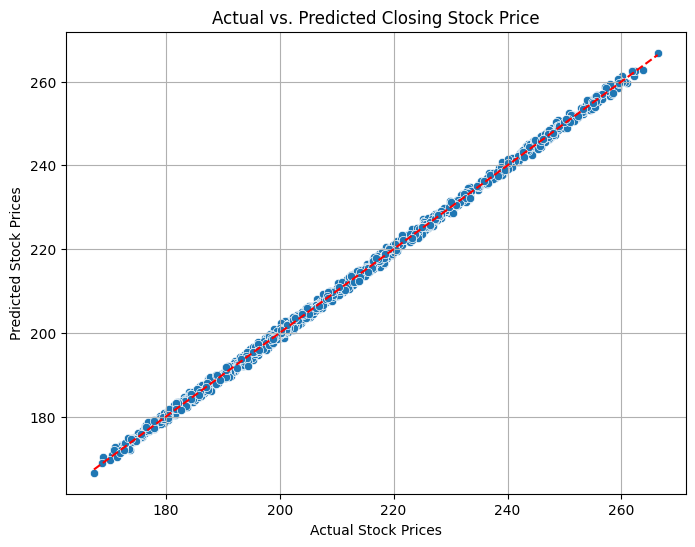

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Stock Prices")
plt.ylabel("Predicted Stock Prices")
plt.title("Actual vs. Predicted Closing Stock Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Add a perfect predictio
plt.grid(True)
plt.show()

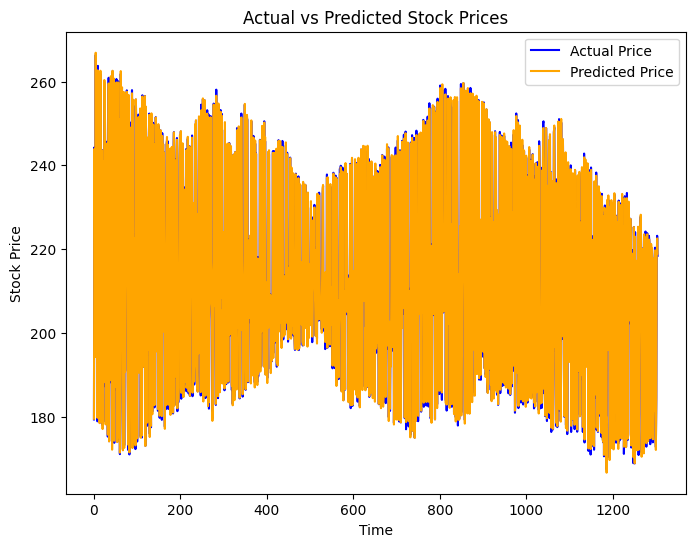

In [24]:
plt.figure(figsize=(8, 6))

plt.plot(y_test.values, label="Actual Price", color="blue")
plt.plot(y_pred, label="Predicted Price", color="orange")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()